# Unified Customer Clustering — K-Means, DBSCAN and Profiling

## Purpose of this notebook

This notebook merges the strongest parts of the previous project workflow:

1. the **K-Means modelling logic from `02_KMeans_Customer_Segmentation.ipynb`**, especially the 11-feature matrix, log-transformed variables, capping of extreme behavioural indicators and standardization;
2. the **DBSCAN logic from `03_DBSCAN_Rigorous_Customer_Patterns_Analysis.ipynb`**, especially the use of DBSCAN as a complementary density/anomaly layer, not as a replacement for K-Means;
3. the **organization and visual comparison style of the last integrated notebook**, including K=3/K=4/K=5 comparison, PCA representations, heatmaps, transition tables and final customer profiling.

## Analytical logic

The workflow is intentionally centralized. Feature engineering, capping and standardization are performed **once**. The same standardized modelling matrix is then used for both K-Means and DBSCAN. This avoids inconsistencies between notebooks.

The final logic is:

- **K-Means** = main business segmentation model. It assigns every customer to one interpretable group.
- **DBSCAN** = complementary density-based model. It checks whether the data contain dense local patterns and flags sparse observations as atypical/noise customers.
- **Profiling** = business interpretation of the final K-Means segments and DBSCAN anomaly layer.


## 0. Imports and global settings

### What we do
We import the libraries required for data loading, preprocessing, clustering, metrics, PCA visualization and plotting.

### Why we do it
K-Means and DBSCAN are distance-based algorithms, so the notebook needs tools for standardization, clustering metrics and dimensionality reduction for visualization.

### Expected outcome
All libraries are loaded successfully and global display/settings are defined once.


In [1]:
# ============================================================
# 0. Imports and global settings
# ============================================================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

warnings.filterwarnings("ignore")

# Display settings. These do not change the analysis; they only make tables easier to read.
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.3f}".format)

# Reproducibility and compatibility settings.
RANDOM_STATE = 42
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

OUTPUT_DIR = Path(".")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load the dataset robustly

### What we do
We load the best available dataset from the current folder, parent folder or `source/` subfolder. The notebook first looks for a feature-engineered dataset, because this corresponds most closely to the original `02_KMeans` workflow. If it is not available, it falls back to `dataset_eda.csv` and recreates the required engineered features.

### Why we do it
Your files have been moved across folders and sometimes exported with different encodings. This robust loader prevents repeated path and encoding errors in VS Code.

### Expected outcome
A DataFrame called `df` is loaded. The notebook prints the path used, the encoding used and the dataset shape.


In [2]:
# ============================================================
# 1. Robust data loading
# ============================================================

SEARCH_DIRS = [
    Path.cwd(),
    Path.cwd() / "source",
    Path.cwd().parent,
    Path.cwd().parent / "source",
    Path("/mnt/data"),
]

FEATURE_ENGINEERED_NAMES = [
    "dataset_feature_engineered.csv",
    "dataset_feature_engineered(1).csv",
    "dataset_feature_engineered(2).csv",
    "dataset_feature_engineered(3).csv",
    "dataset_feature_engineered(4).csv",
    "dataset_feature_engineered(5).csv",
    "dataset_feature_engineered(6).csv",
    "dataset_feature_engineered(7).csv",
    "dataset_feature_engineered(8).csv",
    "dataset_eda_feature_engineered.csv",
]

EDA_NAMES = [
    "dataset_eda.csv",
    "dataset_eda(1).csv",
    "dataset_eda(2).csv",
    "dataset_eda(3).csv",
    "dataset_eda(4).csv",
    "dataset_eda(5).csv",
    "dataset_eda(6).csv",
    "dataset_eda(7).csv",
]

RAW_NAMES = [
    "dataset.csv",
    "dataset(1).csv",
    "dataset(2).csv",
    "dataset(3).csv",
    "dataset(4).csv",
]


def candidate_paths(file_names):
    '''Create possible file paths from candidate directories and file names.'''
    paths = []
    for directory in SEARCH_DIRS:
        for name in file_names:
            paths.append(directory / name)
    return paths


def find_first_existing(paths):
    '''Return the first existing file from a list of candidate paths.'''
    for path in paths:
        if path.exists():
            return path
    return None


def read_csv_robust(path):
    '''Read CSV files exported with different encodings and separators.'''
    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin1", "ISO-8859-1"]
    last_error = None
    for encoding in encodings:
        try:
            df_loaded = pd.read_csv(path, encoding=encoding, sep=None, engine="python")
            return df_loaded, encoding
        except UnicodeDecodeError as error:
            last_error = error
            continue
    raise last_error if last_error is not None else ValueError(f"Unable to read {path}")

feature_path = find_first_existing(candidate_paths(FEATURE_ENGINEERED_NAMES))
eda_path = find_first_existing(candidate_paths(EDA_NAMES))
raw_path = find_first_existing(candidate_paths(RAW_NAMES))

if feature_path is not None:
    input_path = feature_path
    input_type = "feature-engineered"
elif eda_path is not None:
    input_path = eda_path
    input_type = "EDA-cleaned"
elif raw_path is not None:
    input_path = raw_path
    input_type = "raw"
else:
    raise FileNotFoundError(
        "No input dataset was found. Place dataset_feature_engineered.csv, dataset_eda.csv, "
        "or dataset.csv in the notebook folder, parent folder, or source/ subfolder.\n"
        f"Current working directory: {Path.cwd()}"
    )

df, used_encoding = read_csv_robust(input_path)

print(f"Loaded {input_type} dataset: {input_path.resolve()}")
print(f"Encoding used: {used_encoding}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head(3))


Loaded feature-engineered dataset: /Users/sara/Desktop/Master RBS/10 Capstone/data/dataset_feature_engineered.csv
Encoding used: utf-8
Dataset shape: 16,791 rows x 59 columns


,NACE,NACE_Desc,Revenue,Employees,Province,City,Region,M-35,M-34,M-33,M-32,M-31,M-30,M-29,M-28,M-27,M-26,M-25,M-24,M-23,M-22,M-21,M-20,M-19,M-18,M-17,M-16,M-15,M-14,M-13,M-12,M-11,M-10,M-9,M-8,M-7,M-6,M-5,M-4,M-3,M-2,M-1,M-0,total_volume,avg_monthly_volume,recent_volume,past_volume,recent_ratio,volume_trend,trend_pct,volatility,cv_volume,activity_drop_ratio,log_revenue,log_employees,log_total_volume,log_recent_volume,log_avg_monthly_volume,log_volatility
0,47.710,Retail sale of clothing in specialised stores,93840,2,PA,Palermo,Sicilia,80,718,3888,6255,8388,9803,5579,4462,6844,9636,9316,12098,9411,9841,14272,15324,23988,28214,33424,31213,65146,100043,131904,88176,67597,61278,65919,58362,69779,62338,71332,54796,91169,104473,127672,139105,1601843,"44,495.639",588547,1013296,0.367,139025,"1,716.358","41,638.462",0.936,-1.904,11.449,1.099,14.287,13.285,10.703,10.637
1,49.410,Freight transport by road,1242280,4,MB,Monza,Lombardia,44520,43793,54545,52400,61680,54610,57721,31845,59957,52277,65616,61489,58237,56621,72238,58939,75950,61535,62401,36839,62736,66464,73573,77475,64787,69932,78015,73822,83936,68864,107911,37607,100365,105866,84089,95330,2373985,"65,944.028",531168,1842817,0.224,50810,1.141,"18,040.729",0.274,-0.441,14.032,1.609,14.680,13.183,11.097,9.800
2,47.910,Retail sale via mail order houses or via Internet,44451177,159,MI,Milano,Lombardia,65703,87812,65768,59904,146290,116143,113392,87150,75076,63644,107929,175006,56929,63533,72741,54396,89636,61248,47636,44451,48034,44652,59962,118281,39398,46802,35367,41628,60515,57786,85252,76067,86415,75573,101941,237050,2869110,"79,697.500",662298,2206812,0.231,171347,2.608,"40,910.036",0.513,-0.501,17.610,5.075,14.870,13.403,11.286,10.619


## 2. Basic cleaning and column validation

### What we do
We harmonize column names, clean string fields, convert key numerical columns and detect monthly transaction columns such as `M-35`, `M-34`, ..., `M-0`.

### Why we do it
Clustering cannot be trusted if transaction columns are stored as text or if key fields are inconsistent. This step ensures that the later feature-engineering and clustering cells use clean numerical input.

### Expected outcome
Monthly columns are detected and sorted from the oldest month to the most recent month. Numerical fields are converted into numeric dtype.


In [3]:
# ============================================================
# 2. Basic cleaning and column validation
# ============================================================

# Harmonize common Italian names into English names if raw files are used.
rename_map = {
    "Natura": "Nature",
    "Fatturato": "Revenue",
    "Dipendenti": "Employees",
    "Provincia": "Province",
    "ATECO_Desc": "NACE_Desc",
}
df = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns})

# Clean text columns.
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

# Detect monthly columns such as M-35 ... M-0.
month_cols = [c for c in df.columns if str(c).startswith("M-")]
month_cols = sorted(month_cols, key=lambda x: int(str(x).replace("M-", "")), reverse=True)

# Convert numeric columns.
for col in ["Revenue", "Employees"] + month_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# If sector names differ across files, preserve a usable sector proxy.
if "NACE" not in df.columns and "ATECO" in df.columns:
    df["NACE"] = df["ATECO"]
if "NACE_Desc" not in df.columns and "ATECO_Desc" in df.columns:
    df["NACE_Desc"] = df["ATECO_Desc"]

print("Current working directory:", Path.cwd())
print("Rows and columns:", df.shape)
print("Monthly columns detected:", len(month_cols))
if month_cols:
    print("Monthly range:", month_cols[0], "to", month_cols[-1])
else:
    print("No monthly columns detected. If using a feature-engineered dataset, this may still be acceptable.")

print("\nMain data types:")
display(df.dtypes.value_counts())

print("\nMissing values in key columns:")
key_cols_to_check = [col for col in ["Revenue", "Employees", "NACE", "NACE_Desc", "Region", "Province"] if col in df.columns]
display(df[key_cols_to_check].isna().sum().to_frame("missing_values") if key_cols_to_check else pd.DataFrame())


Current working directory: /Users/sara/Desktop/Master RBS/10 Capstone/data
Rows and columns: (16791, 59)
Monthly columns detected: 36
Monthly range: M-35 to M-0

Main data types:


int64      42
float64    13
str         4
Name: count, dtype: int64


Missing values in key columns:


,missing_values
Revenue,0
Employees,0
NACE,0
NACE_Desc,0
Region,0
Province,0


## 3. Feature engineering using the stronger `02_KMeans` logic

### What we do
We create or validate the behavioural variables used in the original K-Means notebook:

- customer size: `log_revenue`, `log_employees`;
- customer value: `log_total_volume`, `log_recent_volume`, `log_avg_monthly_volume`;
- trend: `volume_trend`, `trend_pct`;
- stability: `log_volatility`, `cv_volume`;
- engagement and deterioration: `recent_ratio`, `activity_drop_ratio`.

### Why we do it
This is the stronger feature logic because it describes customer value, activity, trend, volatility and deterioration. These dimensions are directly connected to the business objective of segmentation and churn-risk monitoring.

### Expected outcome
The notebook has the same 11 modelling features used by the old K-Means/DBSCAN logic. If the input file already contains them, they are reused. If not, they are reconstructed from monthly transaction columns.


In [4]:
# ============================================================
# 3. Feature engineering
# ============================================================

# Helper functions for robust calculations.
def safe_log1p(series):
    '''Apply log1p after replacing negative values with 0 for scale variables.'''
    return np.log1p(pd.to_numeric(series, errors="coerce").clip(lower=0))

# If monthly columns exist, reconstruct behavioural features.
# If a feature-engineered file was loaded, this cell still recomputes core features for consistency.
if month_cols:
    recent_cols = [c for c in ["M-5", "M-4", "M-3", "M-2", "M-1", "M-0"] if c in df.columns]
    past_cols = [c for c in month_cols if c not in recent_cols]

    monthly = df[month_cols].fillna(0)

    df["total_volume"] = monthly.sum(axis=1)
    df["avg_monthly_volume"] = monthly.mean(axis=1)
    df["recent_volume"] = df[recent_cols].fillna(0).sum(axis=1) if recent_cols else 0
    df["past_volume"] = df[past_cols].fillna(0).sum(axis=1) if past_cols else 0

    # Recent ratio: share of total volume concentrated in the most recent six months.
    df["recent_ratio"] = df["recent_volume"] / (df["total_volume"].abs() + 1)

    # Trend: compare recent average activity with older average activity.
    recent_months = max(len(recent_cols), 1)
    past_months = max(len(past_cols), 1)
    recent_avg = df["recent_volume"] / recent_months
    past_avg = df["past_volume"] / past_months

    df["volume_trend"] = recent_avg - past_avg
    df["trend_pct"] = (recent_avg - past_avg) / (past_avg.abs() + 1)

    # Volatility: month-to-month dispersion across the full transaction history.
    df["volatility"] = monthly.std(axis=1)
    df["cv_volume"] = df["volatility"] / (df["avg_monthly_volume"].abs() + 1)

    # Activity drop: positive values mean recent activity is below the level expected from the past average.
    expected_recent = past_avg * recent_months
    df["activity_drop_ratio"] = (expected_recent - df["recent_volume"]) / (expected_recent.abs() + 1)
else:
    # If no monthly columns exist, require that the engineered behavioural columns already exist.
    required_engineered = [
        "total_volume", "avg_monthly_volume", "recent_volume", "past_volume",
        "volume_trend", "trend_pct", "volatility", "cv_volume", "recent_ratio", "activity_drop_ratio"
    ]
    missing_required = [col for col in required_engineered if col not in df.columns]
    if missing_required:
        raise ValueError(
            "The dataset has no monthly columns and is missing engineered variables: "
            f"{missing_required}. Use dataset_feature_engineered.csv or dataset_eda.csv."
        )

# Log-transform size and skewed volume variables.
for raw_col, log_col in [
    ("Revenue", "log_revenue"),
    ("Employees", "log_employees"),
    ("total_volume", "log_total_volume"),
    ("recent_volume", "log_recent_volume"),
    ("avg_monthly_volume", "log_avg_monthly_volume"),
    ("volatility", "log_volatility"),
]:
    if raw_col in df.columns:
        df[log_col] = safe_log1p(df[raw_col])

# Final feature set inherited from the stronger 02_KMeans workflow.
FEATURE_COLS = [
    "log_revenue",
    "log_employees",
    "log_total_volume",
    "log_recent_volume",
    "log_avg_monthly_volume",
    "volume_trend",
    "trend_pct",
    "log_volatility",
    "cv_volume",
    "recent_ratio",
    "activity_drop_ratio",
]

missing_features = [col for col in FEATURE_COLS if col not in df.columns]
if missing_features:
    raise ValueError(f"Missing final modelling features: {missing_features}")

print("Final modelling features:", len(FEATURE_COLS))
for i, col in enumerate(FEATURE_COLS, start=1):
    print(f"{i:02d}. {col}")

feature_summary = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).describe().T
feature_summary


Final modelling features: 11
01. log_revenue
02. log_employees
03. log_total_volume
04. log_recent_volume
05. log_avg_monthly_volume
06. volume_trend
07. trend_pct
08. log_volatility
09. cv_volume
10. recent_ratio
11. activity_drop_ratio


,count,mean,std,min,25%,50%,75%,max
log_revenue,"16,791.000",10.817,6.330,0.000,9.119,13.546,15.199,17.875
log_employees,"16,791.000",2.080,1.308,0.000,0.693,1.946,2.944,9.881
log_total_volume,"16,791.000",6.581,2.716,0.693,4.419,6.690,8.619,15.421
log_recent_volume,"16,791.000",3.416,3.418,0.000,0.000,3.045,6.354,13.403
log_avg_monthly_volume,"16,791.000",3.308,2.331,0.027,1.187,3.149,5.042,11.838
volume_trend,"16,791.000",21.391,"2,192.116","-152,097.333",-29.183,-2.633,1.367,"99,026.800"
trend_pct,"16,791.000",4.179,87.050,-1.000,-0.796,-0.333,0.085,"6,538.833"
log_volatility,"16,791.000",3.626,1.933,0.154,2.042,3.517,4.975,12.758
cv_volume,"16,791.000",1.517,1.027,0.094,0.776,1.304,1.958,28.017
recent_ratio,"16,791.000",0.142,0.223,0.000,0.000,0.062,0.179,1.000


## 4. Centralized preprocessing: missing values, capping and standardization

### What we do
We create the final modelling matrix used by both K-Means and DBSCAN:

1. replace infinite values;
2. impute missing values using the median;
3. cap extreme behavioural indicators at the 1st and 99th percentiles;
4. standardize all features using `StandardScaler`.

### Why we do it
K-Means and DBSCAN are both distance-based. Without capping and standardization, extreme values and large-scale variables would dominate distances and distort the segmentation.

### Expected outcome
A clean matrix called `X_scaled` is created. It has 11 standardized features and is reused consistently by K-Means and DBSCAN.


In [5]:
# ============================================================
# 4. Centralized preprocessing
# ============================================================

X_model = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).copy()

# Median imputation is robust to outliers and avoids dropping customers.
median_values = X_model.median(numeric_only=True)
X_model = X_model.fillna(median_values)

# Capping inherited from the stronger 02_KMeans workflow.
# These variables are ratios/trends and can contain extreme values that dominate Euclidean distances.
CAP_COLS = ["volume_trend", "trend_pct", "cv_volume", "activity_drop_ratio"]

cap_limits = []
for col in CAP_COLS:
    lower = X_model[col].quantile(0.01)
    upper = X_model[col].quantile(0.99)
    before_min = X_model[col].min()
    before_max = X_model[col].max()
    X_model[col] = X_model[col].clip(lower=lower, upper=upper)
    cap_limits.append({
        "feature": col,
        "before_min": before_min,
        "p01_lower_cap": lower,
        "p99_upper_cap": upper,
        "before_max": before_max,
    })

cap_limits_df = pd.DataFrame(cap_limits)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=df.index)

print("Number of modelling features:", X_scaled_df.shape[1])
print("Missing values after preprocessing:", int(X_scaled_df.isna().sum().sum()))
print("Mean of standardized features, approximately 0:")
display(X_scaled_df.mean().round(3).to_frame("mean"))
print("Standard deviation of standardized features, approximately 1:")
display(X_scaled_df.std().round(3).to_frame("std"))
print("Capping limits:")
display(cap_limits_df.round(3))


Number of modelling features: 11
Missing values after preprocessing: 0
Mean of standardized features, approximately 0:


,mean
log_revenue,-0.000
log_employees,0.000
log_total_volume,-0.000
log_recent_volume,-0.000
log_avg_monthly_volume,0.000
volume_trend,-0.000
trend_pct,-0.000
log_volatility,0.000
cv_volume,-0.000
recent_ratio,0.000


Standard deviation of standardized features, approximately 1:


,std
log_revenue,1.000
log_employees,1.000
log_total_volume,1.000
log_recent_volume,1.000
log_avg_monthly_volume,1.000
volume_trend,1.000
trend_pct,1.000
log_volatility,1.000
cv_volume,1.000
recent_ratio,1.000


Capping limits:


,feature,before_min,p01_lower_cap,p99_upper_cap,before_max
0,volume_trend,"-152,097.333","-1,786.633","2,905.097","99,026.800"
1,trend_pct,-1.000,-0.999,40.850,"6,538.833"
2,cv_volume,0.094,0.232,5.076,28.017
3,activity_drop_ratio,"-39,233.000",-155.200,1.000,1.000


## 5. Correlation diagnostic of the modelling features

### What we do
We visualize the correlation matrix of the 11 modelling variables after cleaning and capping.

### Why we do it
Highly correlated features can reinforce some dimensions of customer behaviour. This is not necessarily wrong, but it should be visible before clustering.

### Expected outcome
A heatmap showing how value, trend, volatility and deterioration features relate to each other.


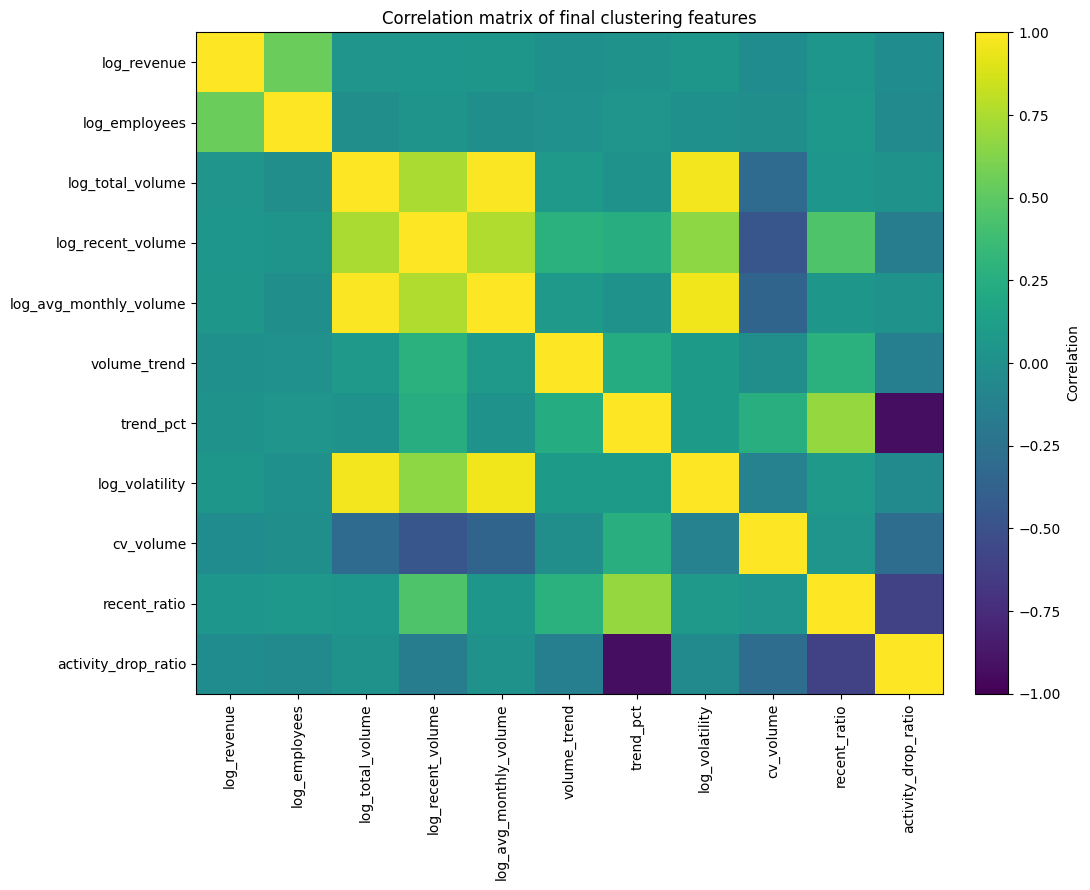

In [6]:
# ============================================================
# 5. Correlation diagnostic
# ============================================================

corr = X_model[FEATURE_COLS].corr()

plt.figure(figsize=(11, 9))
im = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(FEATURE_COLS)), FEATURE_COLS, rotation=90)
plt.yticks(range(len(FEATURE_COLS)), FEATURE_COLS)
plt.title("Correlation matrix of final clustering features")
plt.tight_layout()
plt.show()


## 6. K-Means model selection: K = 3, K = 4 and K = 5

### What we do
We fit K-Means for K=3, K=4 and K=5 using the same standardized matrix and compare:

- inertia;
- silhouette score;
- Davies-Bouldin score;
- Calinski-Harabasz score;
- cluster sizes.

### Why we do it
The previous integrated notebook made the comparison easier to explain visually. Here we keep that representation, but we apply it to the stronger 11-feature matrix from `02_KMeans`.

### Expected outcome
A comparison table and plots supporting the final choice of **K = 4** as the best compromise between statistical quality and business interpretability.


In [7]:
# ============================================================
# 6. K-Means comparison for K = 3, 4, 5
# ============================================================

K_CANDIDATES = [3, 4, 5]
comparison_results = []
kmeans_labels = {}
kmeans_models = {}

for k in K_CANDIDATES:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
        algorithm="lloyd",
    )
    labels = model.fit_predict(X_scaled)
    kmeans_labels[k] = labels
    kmeans_models[k] = model

    counts = pd.Series(labels).value_counts().sort_index()
    comparison_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Smallest cluster": int(counts.min()),
        "Largest cluster": int(counts.max()),
        "Largest cluster share %": counts.max() / len(labels) * 100,
    })

kmeans_comparison = pd.DataFrame(comparison_results)

print("K-Means comparison metrics:")
display(kmeans_comparison.round(4))

# Save labels for comparison and profiling.
for k, labels in kmeans_labels.items():
    df[f"kmeans_k{k}"] = labels


K-Means comparison metrics:


,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Smallest cluster,Largest cluster,Largest cluster share %
0,3,"105,837.945",0.301,1.086,"6,254.623",287,9049,53.892
1,4,"93,142.178",0.249,1.220,"5,500.544",287,6398,38.104
2,5,"81,610.591",0.270,1.111,"5,301.014",275,6373,37.955


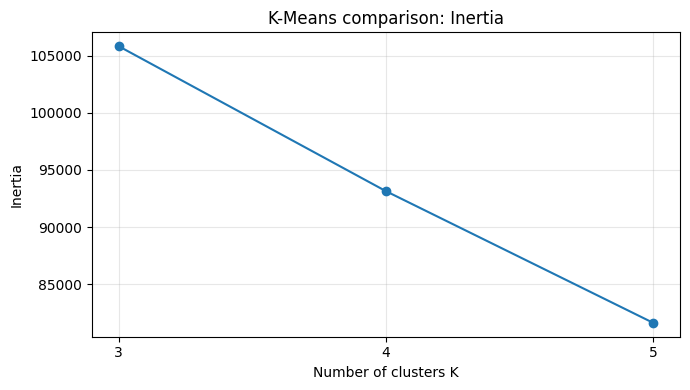

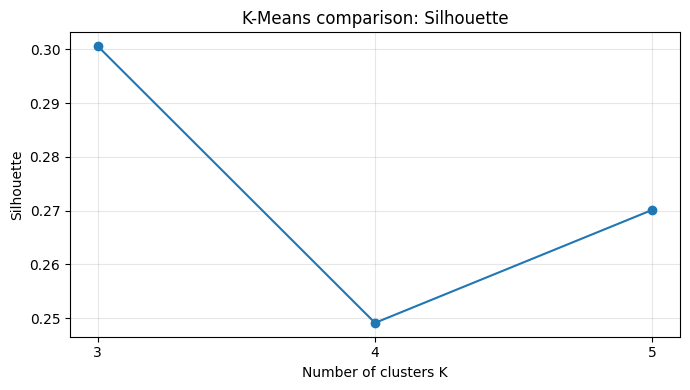

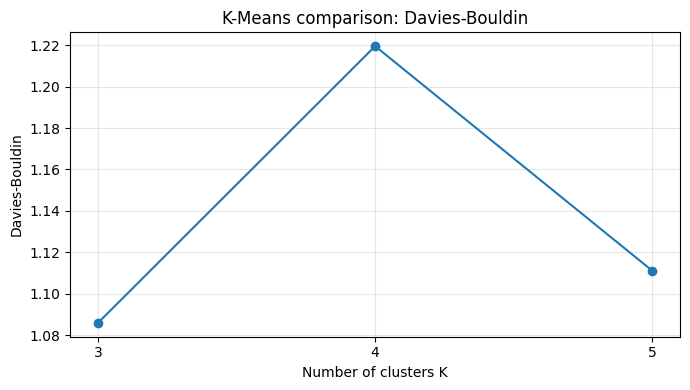

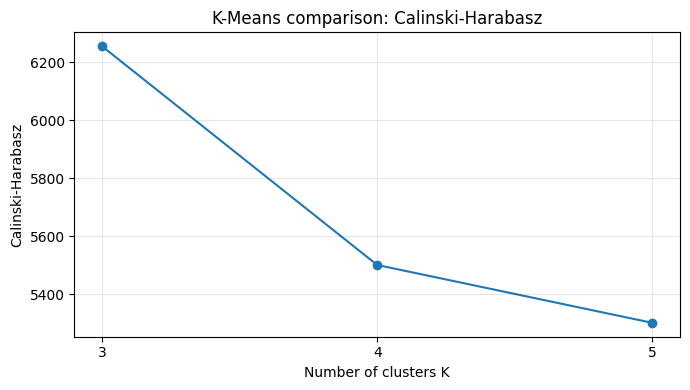

In [8]:
# ============================================================
# 6.1 Visual comparison of K-Means metrics
# ============================================================

metric_columns = ["Inertia", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]

for metric in metric_columns:
    plt.figure(figsize=(7, 4))
    plt.plot(kmeans_comparison["K"], kmeans_comparison[metric], marker="o")
    plt.xticks(K_CANDIDATES)
    plt.title(f"K-Means comparison: {metric}")
    plt.xlabel("Number of clusters K")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7. K-Means cluster-size comparison

### What we do
We compare how many customers are assigned to each cluster for K=3, K=4 and K=5.

### Why we do it
A technically good clustering solution can still be weak if it creates overly broad groups or too many small, hard-to-manage segments. Cluster-size distribution helps judge managerial usability.

### Expected outcome
A visual comparison showing whether K=3 is too coarse and whether K=5 fragments the customer base too much.


K=3 cluster sizes:


,cluster,customers,share_%
0,0,7455,44.399
1,1,287,1.709
2,2,9049,53.892


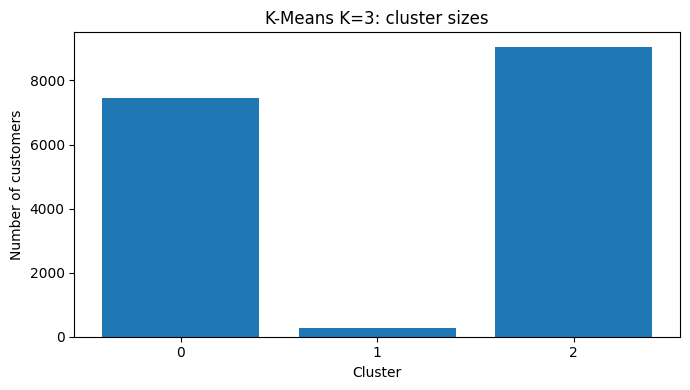

K=4 cluster sizes:


,cluster,customers,share_%
0,0,3941,23.471
1,1,287,1.709
2,2,6165,36.716
3,3,6398,38.104


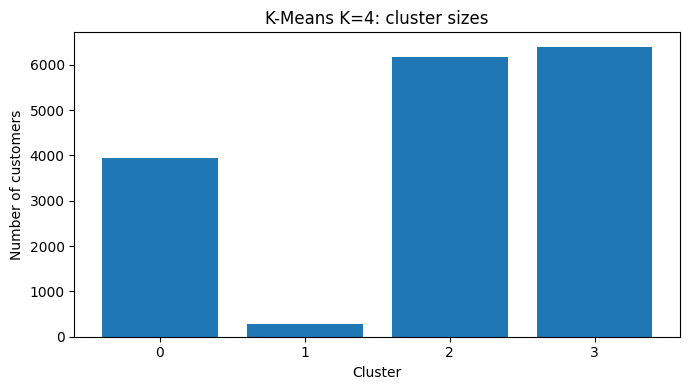

K=5 cluster sizes:


,cluster,customers,share_%
0,0,429,2.555
1,1,6171,36.752
2,2,6373,37.955
3,3,275,1.638
4,4,3543,21.101


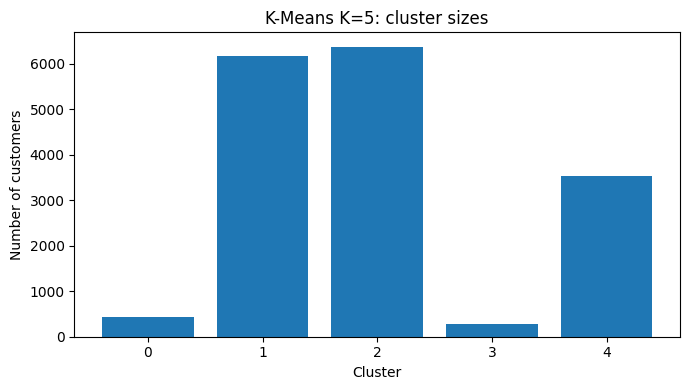

In [9]:
# ============================================================
# 7. K-Means cluster-size comparison
# ============================================================

for k in K_CANDIDATES:
    size_table = (
        df[f"kmeans_k{k}"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="customers")
    )
    size_table["share_%"] = size_table["customers"] / len(df) * 100

    print(f"K={k} cluster sizes:")
    display(size_table.round(3))

    plt.figure(figsize=(7, 4))
    plt.bar(size_table["cluster"].astype(str), size_table["customers"])
    plt.title(f"K-Means K={k}: cluster sizes")
    plt.xlabel("Cluster")
    plt.ylabel("Number of customers")
    plt.tight_layout()
    plt.show()


## 8. K-Means profiling for K=3, K=4 and K=5

### What we do
We profile each K solution using business variables such as revenue, employees, volume, trend, volatility and activity drop.

### Why we do it
The final K is not selected only by metrics. A useful segmentation must produce interpretable and actionable customer groups.

### Expected outcome
The K=4 solution should provide a richer structure than K=3 while avoiding the over-fragmentation risk of K=5.


In [10]:
# ============================================================
# 8. K-Means profiles
# ============================================================

BUSINESS_COLS = [
    "Revenue",
    "Employees",
    "total_volume",
    "recent_volume",
    "past_volume",
    "avg_monthly_volume",
    "volume_trend",
    "trend_pct",
    "volatility",
    "cv_volume",
    "recent_ratio",
    "activity_drop_ratio",
]
BUSINESS_COLS = [col for col in BUSINESS_COLS if col in df.columns]

profile_tables = {}

for k in K_CANDIDATES:
    label_col = f"kmeans_k{k}"
    profile = (
        df.groupby(label_col)[BUSINESS_COLS]
        .agg(["count", "mean", "median"])
        .round(3)
    )
    profile_tables[k] = profile
    print(f"K={k} business profile:")
    display(profile)


K=3 business profile:


Revenue                             Employees               total_volume                      recent_volume                   past_volume                       \
            count          mean        median     count   mean median        count       mean    median         count      mean  median       count       mean    median   
kmeans_k3                                                                                                                                                                  
0            7455 4,305,622.054   752,624.000      7455 26.764  6.000         7455 35,606.769 6,757.000          7455 6,041.721 715.000        7455 29,565.048 5,731.000   
1             287 5,608,010.143 1,738,573.000       287 25.369 11.000          287  6,007.606   673.000           287 5,667.017 667.000         287    340.589     0.000   
2            9049 4,310,699.148   762,758.000      9049 21.857  6.000         9049    308.546   103.000          9049    13.543   0.000        9049    295.003    93.000   

          avg_monthly_volume                 volume_trend                 trend_pct                volatility                 cv_volume              recent_ratio               \
                       count    mean  median        count    mean  median     count    mean median      count    mean  median     count  mean median        count  mean median   
kmeans_k3                                                                                                                                                                        
0                       7455 989.077 187.694         7455  21.452 -21.000      7455   0.282 -0.154       7455 689.968 155.402      7455 0.978  0.778         7455 0.162  0.144   
1                        287 166.878  18.694          287 933.150 111.033       287 242.533 48.833        287 493.933  71.581       287 3.641  3.497          287 0.974  0.994   
2                       9049   8.571   2.861         9049  -7.576  -1.633      9049  -0.170 -0.524       9049  21.126   7.757      9049 1.894  1.660         9049 0.099  0.000   

          activity_drop_ratio                      
                        count       mean   median  
kmeans_k3                                          
0                        7455     -0.303    0.155  
1                         287 -1,208.398 -200.000  
2                        9049     -0.458    0.828

K=4 business profile:


Revenue                             Employees               total_volume                      recent_volume                     past_volume                       \
            count          mean        median     count   mean median        count       mean    median         count      mean    median       count       mean    median   
kmeans_k4                                                                                                                                                                    
0            3941    43,661.624         0.000      3941  2.687  1.000         3941  1,077.213   416.000          3941    71.238     0.000        3941  1,005.975   365.000   
1             287 5,608,010.143 1,738,573.000       287 25.369 11.000          287  6,007.606   673.000           287 5,667.017   667.000         287    340.589     0.000   
2            6165 6,552,347.474 2,549,600.000      6165 32.322 12.000         6165    262.406    67.000          6165    13.432     0.000        6165    248.975    59.000   
3            6398 4,773,153.543 1,112,951.000      6398 29.299  7.000         6398 41,009.293 8,720.000          6398 7,002.191 1,036.000        6398 34,007.102 7,381.000   

          avg_monthly_volume                   volume_trend                 trend_pct                volatility                 cv_volume              recent_ratio               \
                       count      mean  median        count    mean  median     count    mean median      count    mean  median     count  mean median        count  mean median   
kmeans_k4                                                                                                                                                                          
0                       3941    29.923  11.556         3941 -21.659  -4.667      3941  -0.238 -0.600       3941  53.384  19.233      3941 1.761  1.544         3941 0.086  0.000   
1                        287   166.878  18.694          287 933.150 111.033       287 242.533 48.833        287 493.933  71.581       287 3.641  3.497          287 0.974  0.994   
2                       6165     7.289   1.861         6165  -6.061  -1.100      6165  -0.085 -0.464       6165  17.821   5.942      6165 1.868  1.629         6165 0.113  0.000   
3                       6398 1,139.147 242.222         6398  33.462 -21.817      6398   0.317 -0.131       6398 783.780 185.134      6398 0.933  0.724         6398 0.166  0.148   

          activity_drop_ratio                      
                        count       mean   median  
kmeans_k4                                          
0                        3941      0.068    0.808  
1                         287 -1,208.398 -200.000  
2                        6165     -0.736    0.800  
3                        6398     -0.334    0.131

K=5 business profile:


Revenue                             Employees               total_volume                         recent_volume                       past_volume                         \
            count          mean        median     count   mean median        count        mean      median         count       mean     median       count        mean     median   
kmeans_k5                                                                                                                                                                           
0             429 4,959,434.744 1,242,280.000       429 25.434  7.000          429 229,761.473 100,111.000           429 59,414.751 28,822.000         429 170,346.723 67,920.000   
1            6171 6,382,042.883 2,419,908.000      6171 31.372 12.000         6171     241.936      67.000          6171     11.837      0.000        6171     230.099     60.000   
2            6373 4,648,680.059 1,024,300.000      6373 28.777  7.000         6373  25,927.708   7,023.000          6373  3,064.143    751.000        6373  22,863.565  6,054.000   
3             275 5,513,616.098 1,738,573.000       275 25.647 11.000          275   5,539.047     637.000           275  5,293.538    613.000         275     245.509      0.000   
4            3543    17,488.384         0.000      3543  2.719  1.000         3543     887.240     337.000          3543     69.017      0.000        3543     818.224    293.000   

          avg_monthly_volume                     volume_trend                     trend_pct                volatility                     cv_volume              recent_ratio  \
                       count      mean    median        count      mean    median     count    mean median      count      mean    median     count  mean median        count   
kmeans_k5                                                                                                                                                                       
0                        429 6,382.263 2,780.861          429 4,224.234 1,940.333       429   2.924  1.073        429 3,741.509 1,996.013       429 0.969  0.817          429   
1                       6171     6.720     1.861         6171    -5.697    -1.133      6171  -0.091 -0.474       6171    17.292     5.976      6171 1.898  1.657         6171   
2                       6373   720.214   195.083         6373  -251.428   -30.200      6373   0.118 -0.189       6373   546.827   156.456      6373 0.962  0.752         6373   
3                        275   153.862    17.694          275   874.073   101.367       275 252.183 51.167        275   469.653    68.772       275 3.689  3.520          275   
4                       3543    24.646     9.361         3543   -15.771    -3.667      3543  -0.174 -0.559       3543    42.546    16.781      3543 1.749  1.549         3543   

                       activity_drop_ratio                      
           mean median               count       mean   median  
kmeans_k5                                                       
0         0.358  0.293                 429     -2.940   -1.074  
1         0.112  0.000                6171     -0.751    0.808  
2         0.149  0.139                6373     -0.134    0.190  
3         0.977  0.995                 275 -1,259.325 -205.490  
4         0.091  0.000                3543     -0.043    0.783

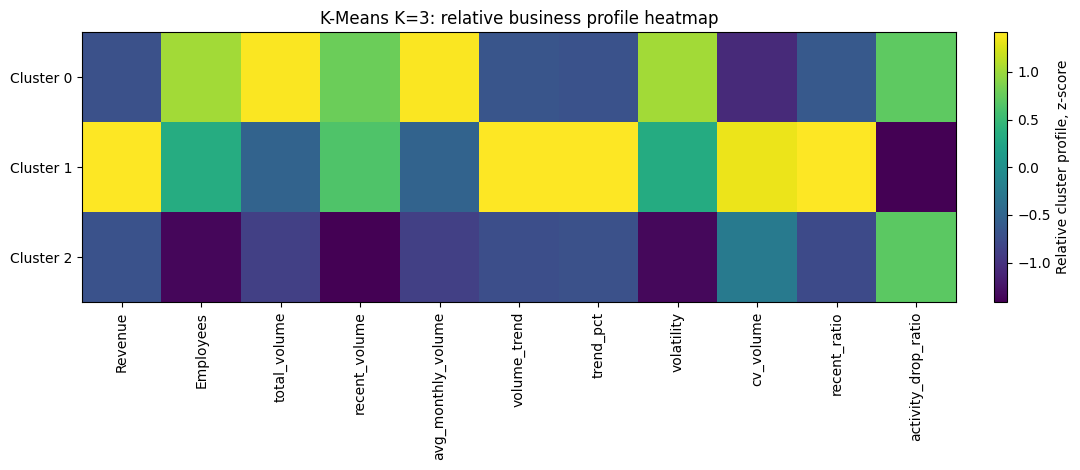

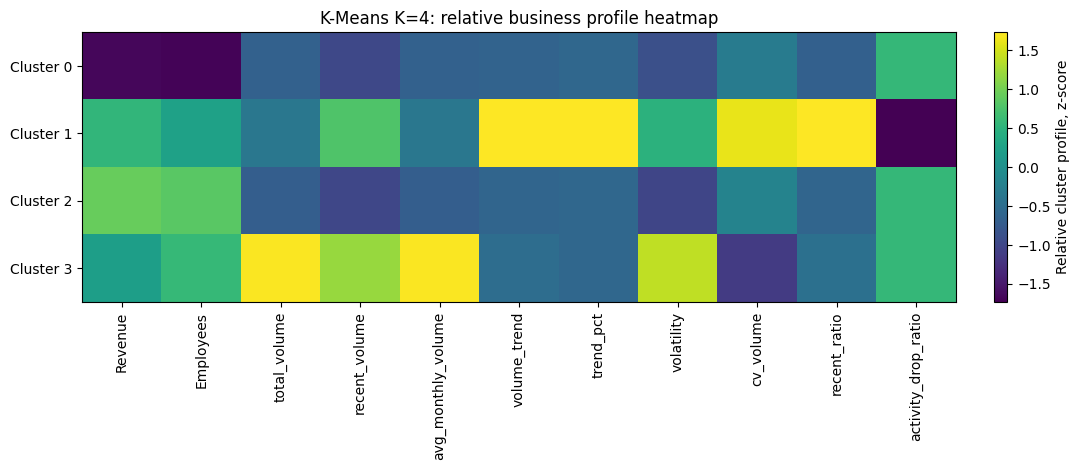

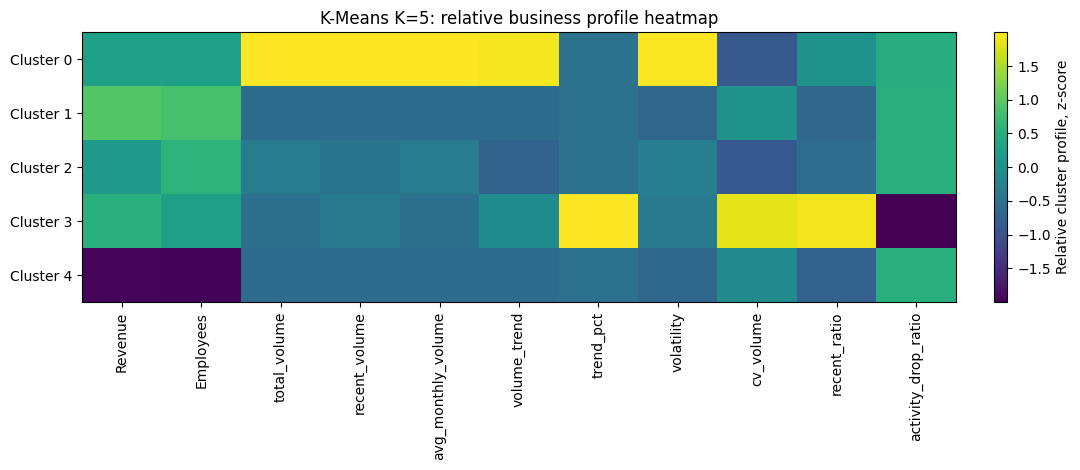

In [11]:
# ============================================================
# 8.1 Z-scored heatmaps for K=3, K=4 and K=5
# ============================================================

# Heatmaps are based on cluster means of business variables.
# Values are standardized across clusters so that darker/lighter cells indicate
# whether a cluster is high or low relative to the other clusters.

heatmap_cols = [
    "Revenue",
    "Employees",
    "total_volume",
    "recent_volume",
    "avg_monthly_volume",
    "volume_trend",
    "trend_pct",
    "volatility",
    "cv_volume",
    "recent_ratio",
    "activity_drop_ratio",
]
heatmap_cols = [col for col in heatmap_cols if col in df.columns]

for k in K_CANDIDATES:
    label_col = f"kmeans_k{k}"
    means = df.groupby(label_col)[heatmap_cols].mean()
    z = (means - means.mean()) / means.std(ddof=0).replace(0, np.nan)
    z = z.fillna(0)

    plt.figure(figsize=(11, 4.8))
    im = plt.imshow(z.values, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Relative cluster profile, z-score")
    plt.xticks(range(len(z.columns)), z.columns, rotation=90)
    plt.yticks(range(len(z.index)), [f"Cluster {idx}" for idx in z.index])
    plt.title(f"K-Means K={k}: relative business profile heatmap")
    plt.tight_layout()
    plt.show()


## 9. Transition tables: how K=4 improves on K=3 and avoids K=5 fragmentation

### What we do
We create cross-tabulations comparing:

- K=3 vs K=4;
- K=4 vs K=5.

### Why we do it
This directly explains the model-selection logic:

- K=3 is usually too coarse because it merges customer behaviours that should be treated differently.
- K=5 may split one meaningful business segment into smaller technical subgroups without adding enough managerial value.
- K=4 is retained as the best balance.

### Expected outcome
Tables showing how the K=4 solution refines K=3 and how K=5 subdivides K=4.


In [12]:
# ============================================================
# 9. Transition tables between K solutions
# ============================================================

k3_k4 = pd.crosstab(df["kmeans_k3"], df["kmeans_k4"], normalize="index") * 100
k4_k5 = pd.crosstab(df["kmeans_k4"], df["kmeans_k5"], normalize="index") * 100

print("How K=4 splits K=3 clusters (% by K=3 row):")
display(k3_k4.round(2))

print("How K=5 splits K=4 clusters (% by K=4 row):")
display(k4_k5.round(2))


How K=4 splits K=3 clusters (% by K=3 row):


kmeans_k4,0,1,2,3
kmeans_k3,,,,
0,12.460,0.000,1.740,85.790
1,0.000,100.000,0.000,0.000
2,33.290,0.000,66.690,0.020


How K=5 splits K=4 clusters (% by K=4 row):


kmeans_k5,0,1,2,3,4
kmeans_k4,,,,,
0,0.000,4.190,6.270,0.000,89.550
1,2.090,1.050,0.350,95.820,0.700
2,0.000,97.370,2.470,0.000,0.160
3,6.610,0.000,93.360,0.000,0.030


## 10. PCA visualization of K-Means solutions

### What we do
We project the 11-dimensional standardized feature matrix into two PCA components and plot K=3, K=4 and K=5 labels.

### Why we do it
PCA gives a visual approximation of the clustering structure. It does not replace the full-dimensional model, but it helps communicate the differences between K choices.

### Expected outcome
Three comparable plots showing how the segmentation changes when moving from K=3 to K=4 and K=5.


PCA explained variance ratio: [0.3446 0.2427]
Total explained variance by PC1 + PC2: 58.73 %


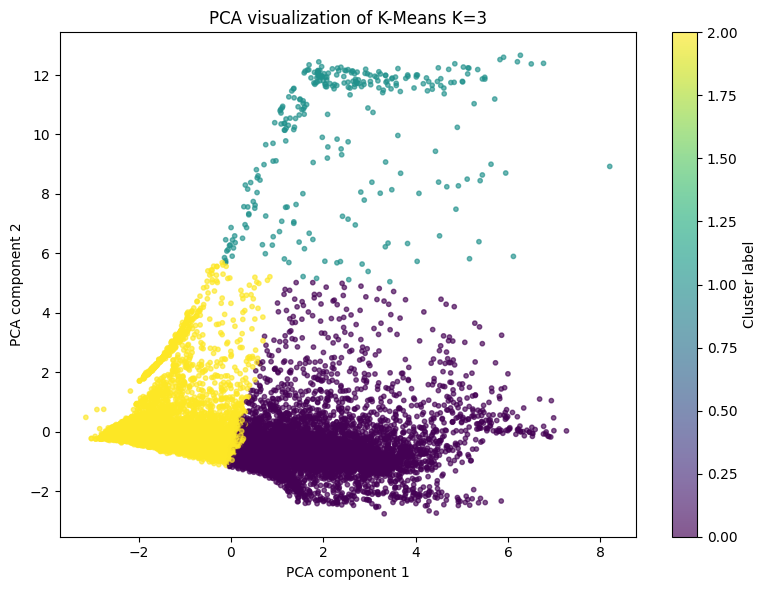

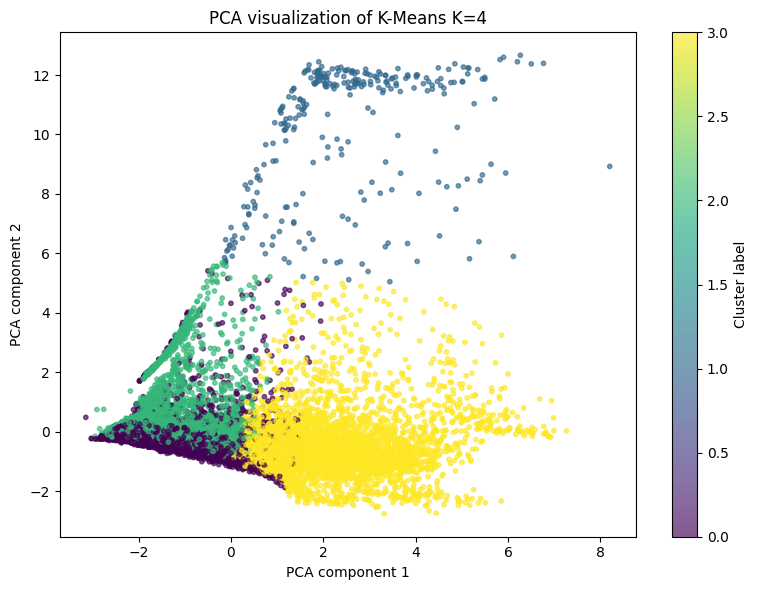

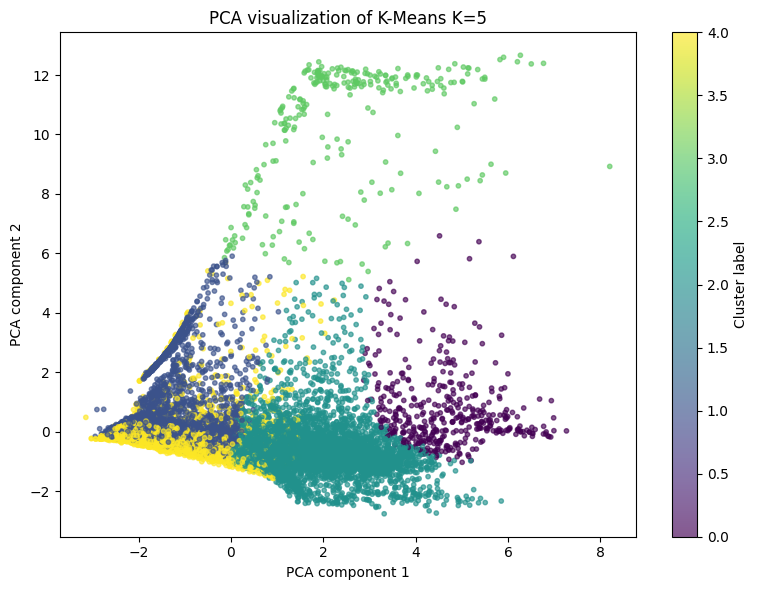

In [13]:
# ============================================================
# 10. PCA visualization for K-Means
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance by PC1 + PC2:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

for k in K_CANDIDATES:
    label_col = f"kmeans_k{k}"
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        df["pca_1"],
        df["pca_2"],
        c=df[label_col],
        s=10,
        alpha=0.65,
    )
    plt.title(f"PCA visualization of K-Means K={k}")
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.colorbar(scatter, label="Cluster label")
    plt.tight_layout()
    plt.show()


## 11. Final K-Means model: K = 4

### What we do
We select K=4 as the final K-Means segmentation model and assign a final segment label to each customer.

### Why K=4 is retained
K=3 is often too compressed: it tends to merge customers that should receive different commercial actions. K=5 may add technical detail, but it risks fragmenting the segmentation without clear extra business value. K=4 is the best compromise because it produces enough behavioural differentiation while remaining manageable for business use.

### Expected outcome
Each customer receives:

- `kmeans_cluster`: final K=4 numerical label;
- `kmeans_segment`: business interpretation of the segment.


In [14]:
# ============================================================
# 11. Final K-Means model and segment naming
# ============================================================

FINAL_K = 4
df["kmeans_cluster"] = df[f"kmeans_k{FINAL_K}"]

# Profile final clusters for automatic business labelling.
final_cluster_means = df.groupby("kmeans_cluster")[BUSINESS_COLS].mean()

# Build a simple, transparent rule-based naming system.
# The names are generated from relative business characteristics, then displayed for review.
cluster_names = {}
available_clusters = set(final_cluster_means.index.tolist())

# Strategic / high-value active: highest total volume.
if "total_volume" in final_cluster_means.columns:
    strategic_cluster = final_cluster_means["total_volume"].idxmax()
    cluster_names[strategic_cluster] = "Strategic / high-value active"
    available_clusters.discard(strategic_cluster)

# Churn-risk / declining: highest activity drop ratio or lowest recent ratio.
if available_clusters:
    if "activity_drop_ratio" in final_cluster_means.columns:
        declining_cluster = final_cluster_means.loc[list(available_clusters), "activity_drop_ratio"].idxmax()
    elif "recent_ratio" in final_cluster_means.columns:
        declining_cluster = final_cluster_means.loc[list(available_clusters), "recent_ratio"].idxmin()
    else:
        declining_cluster = list(available_clusters)[0]
    cluster_names[declining_cluster] = "Churn-risk / declining"
    available_clusters.discard(declining_cluster)

# Growth / opportunity: highest trend_pct or volume_trend among remaining clusters.
if available_clusters:
    if "trend_pct" in final_cluster_means.columns:
        growth_cluster = final_cluster_means.loc[list(available_clusters), "trend_pct"].idxmax()
    elif "volume_trend" in final_cluster_means.columns:
        growth_cluster = final_cluster_means.loc[list(available_clusters), "volume_trend"].idxmax()
    else:
        growth_cluster = list(available_clusters)[0]
    cluster_names[growth_cluster] = "Recent-growth / opportunity"
    available_clusters.discard(growth_cluster)

# Remaining cluster: stable / low-activity depending on size.
for cluster in available_clusters:
    cluster_names[cluster] = "Stable / lower-intensity customers"

# Apply names.
df["kmeans_segment"] = df["kmeans_cluster"].map(cluster_names)

segment_distribution = (
    df.groupby(["kmeans_cluster", "kmeans_segment"])
    .size()
    .reset_index(name="customers")
    .sort_values("kmeans_cluster")
)
segment_distribution["share_%"] = segment_distribution["customers"] / len(df) * 100

print("Final K=4 segment distribution:")
display(segment_distribution.round(3))

print("Final K=4 cluster means used for interpretation:")
display(final_cluster_means.round(3))


Final K=4 segment distribution:


,kmeans_cluster,kmeans_segment,customers,share_%
0,0,Churn-risk / declining,3941,23.471
1,1,Recent-growth / opportunity,287,1.709
2,2,Stable / lower-intensity customers,6165,36.716
3,3,Strategic / high-value active,6398,38.104


Final K=4 cluster means used for interpretation:


,Revenue,Employees,total_volume,recent_volume,past_volume,avg_monthly_volume,volume_trend,trend_pct,volatility,cv_volume,recent_ratio,activity_drop_ratio
kmeans_cluster,,,,,,,,,,,,
0,"43,661.624",2.687,"1,077.213",71.238,"1,005.975",29.923,-21.659,-0.238,53.384,1.761,0.086,0.068
1,"5,608,010.143",25.369,"6,007.606","5,667.017",340.589,166.878,933.150,242.533,493.933,3.641,0.974,"-1,208.398"
2,"6,552,347.474",32.322,262.406,13.432,248.975,7.289,-6.061,-0.085,17.821,1.868,0.113,-0.736
3,"4,773,153.543",29.299,"41,009.293","7,002.191","34,007.102","1,139.147",33.462,0.317,783.780,0.933,0.166,-0.334


## 12. Written conclusion: why K=4 is preferred over K=3 and K=5

### What we do
We summarize the K-Means model-selection conclusion in thesis-ready language.

### Why we do it
The final report needs a defensible explanation that combines metrics and business interpretation. This cell generates a concise reusable conclusion.

### Expected outcome
A clear text explaining why K=4 is the final K-Means segmentation model.


In [15]:
# ============================================================
# 12. K-Means selection conclusion
# ============================================================

k3 = kmeans_comparison.loc[kmeans_comparison["K"] == 3].iloc[0]
k4 = kmeans_comparison.loc[kmeans_comparison["K"] == 4].iloc[0]
k5 = kmeans_comparison.loc[kmeans_comparison["K"] == 5].iloc[0]

inertia_reduction_3_to_4 = (k3["Inertia"] - k4["Inertia"]) / k3["Inertia"] * 100
inertia_reduction_4_to_5 = (k4["Inertia"] - k5["Inertia"]) / k4["Inertia"] * 100

conclusion_text = f'''
K=4 was selected as the final K-Means solution because it provides the best balance between quantitative diagnostics and business interpretability.

Compared with K=3, K=4 reduces inertia by {inertia_reduction_3_to_4:.2f}%, meaning that customers are represented by more precise centroids. More importantly, K=4 separates customer behaviours that K=3 tends to merge into broader groups. This is relevant because stable customers, declining customers, high-value customers and growth/opportunity customers require different managerial actions.

Compared with K=5, the additional reduction in inertia is {inertia_reduction_4_to_5:.2f}%. K=5 may add technical granularity, but it risks fragmenting the segmentation without necessarily producing a new segment that is easier to act on. For this reason, K=4 is retained as the most useful business segmentation model.

The final segmentation therefore prioritizes interpretability and actionability, not only the absolute best value of a single clustering metric.
'''

print(conclusion_text)



K=4 was selected as the final K-Means solution because it provides the best balance between quantitative diagnostics and business interpretability.

Compared with K=3, K=4 reduces inertia by 12.00%, meaning that customers are represented by more precise centroids. More importantly, K=4 separates customer behaviours that K=3 tends to merge into broader groups. This is relevant because stable customers, declining customers, high-value customers and growth/opportunity customers require different managerial actions.

Compared with K=5, the additional reduction in inertia is 12.38%. K=5 may add technical granularity, but it risks fragmenting the segmentation without necessarily producing a new segment that is easier to act on. For this reason, K=4 is retained as the most useful business segmentation model.

The final segmentation therefore prioritizes interpretability and actionability, not only the absolute best value of a single clustering metric.



# DBSCAN analysis

## 13. DBSCAN role and parameter strategy

### What we do
We apply DBSCAN to the same standardized 11-feature matrix used by K-Means.

### Why we do it
DBSCAN answers a different question from K-Means. K-Means partitions every customer into one of four business segments. DBSCAN identifies dense regions and labels sparse observations as noise. This makes DBSCAN useful as an anomaly-detection and validation layer.

### Expected outcome
DBSCAN should not be interpreted as a replacement for K-Means. The key output is the distinction between dense customers and atypical/noise customers.


In [16]:
# ============================================================
# 13. DBSCAN setup
# ============================================================

X_dbscan = X_scaled
n_features = X_dbscan.shape[1]
DBSCAN_BASE_MIN_SAMPLES = 2 * n_features

# Candidate values for sensitivity analysis.
# The final baseline is 2 × number of features, which gives 22 with the current 11-feature matrix.
min_samples_candidates = sorted(set([
    max(5, int(np.log(len(X_dbscan)))),   # loose benchmark, similar to the colleague-style approach
    max(5, n_features),                  # moderate density requirement
    max(5, DBSCAN_BASE_MIN_SAMPLES),     # final rule: 2 × features
    max(5, 3 * n_features),              # stricter sensitivity case
]))

eps_percentiles = [80, 85, 90, 92, 95, 97]

print("DBSCAN input matrix: same standardized 11-feature matrix used by K-Means")
print("Number of DBSCAN features:", n_features)
print("Final-rule min_samples = 2 × features =", DBSCAN_BASE_MIN_SAMPLES)
print("min_samples candidates:", min_samples_candidates)
print("eps percentiles tested:", eps_percentiles)


DBSCAN input matrix: same standardized 11-feature matrix used by K-Means
Number of DBSCAN features: 11
Final-rule min_samples = 2 × features = 22
min_samples candidates: [9, 11, 22, 33]
eps percentiles tested: [80, 85, 90, 92, 95, 97]


## 14. DBSCAN k-distance diagnostic

### What we do
For each `min_samples` candidate, we compute the distance from each customer to its kth nearest neighbour. Candidate `eps` values are extracted from percentiles of this distance distribution.

### Why we do it
DBSCAN requires `eps`, the radius used to define neighbourhood density. The k-distance curve is the standard diagnostic for choosing `eps`. Lower percentiles are stricter and create more noise; higher percentiles are looser and absorb more customers into dense clusters.

### Expected outcome
A table of candidate `eps` values and a k-distance plot for the final baseline `min_samples = 22`.


Candidate eps values from k-distance percentiles:


,min_samples,q80,q85,q90,q92,q95,q97
0,9,0.604,0.691,0.815,0.895,1.082,1.315
1,11,0.642,0.731,0.863,0.949,1.149,1.419
2,22,0.782,0.890,1.064,1.171,1.414,1.738
3,33,0.871,0.995,1.203,1.321,1.593,1.952


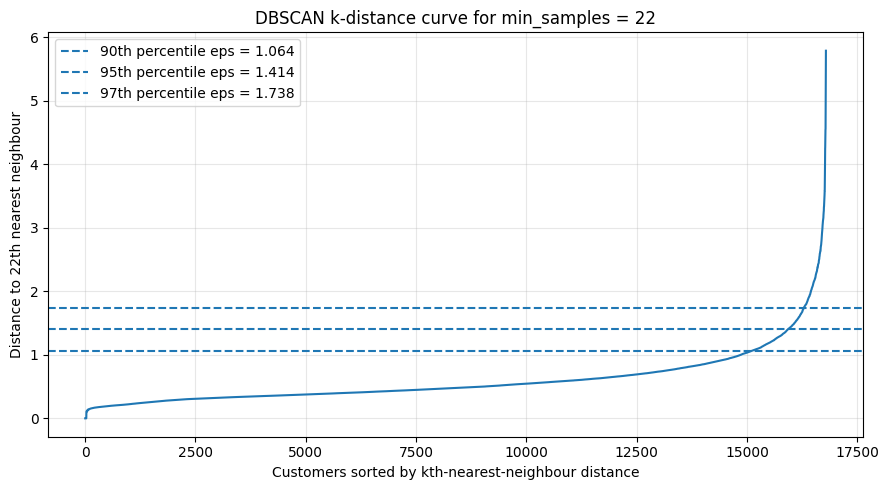

In [17]:
# ============================================================
# 14. DBSCAN k-distance diagnostic
# ============================================================

k_distance_values = {}
k_distance_summary_rows = []

for min_samples in min_samples_candidates:
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(X_dbscan)
    distances, _ = neighbors.kneighbors(X_dbscan)
    k_distances = np.sort(distances[:, -1])
    k_distance_values[min_samples] = k_distances

    row = {"min_samples": min_samples}
    for percentile in eps_percentiles:
        row[f"q{percentile}"] = float(np.percentile(k_distances, percentile))
    k_distance_summary_rows.append(row)

k_distance_summary = pd.DataFrame(k_distance_summary_rows)
print("Candidate eps values from k-distance percentiles:")
display(k_distance_summary.round(4))

main_k = DBSCAN_BASE_MIN_SAMPLES
main_k_distances = k_distance_values[main_k]

plt.figure(figsize=(9, 5))
plt.plot(main_k_distances)
for percentile in [90, 95, 97]:
    eps_value = float(np.percentile(main_k_distances, percentile))
    plt.axhline(eps_value, linestyle="--", label=f"{percentile}th percentile eps = {eps_value:.3f}")
plt.title(f"DBSCAN k-distance curve for min_samples = {main_k}")
plt.xlabel("Customers sorted by kth-nearest-neighbour distance")
plt.ylabel(f"Distance to {main_k}th nearest neighbour")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. DBSCAN parameter investigation

### What we do
We test combinations of `min_samples` and `eps` percentiles and calculate:

- number of dense clusters excluding noise;
- number and percentage of noise customers;
- largest cluster share;
- number of very small clusters;
- silhouette, Davies-Bouldin and Calinski-Harabasz on non-noise points when valid.

### Why we do it
DBSCAN should not be selected only by silhouette. Noise points are excluded from some metrics, so silhouette can be artificially high. The correct business question is whether DBSCAN preserves a meaningful anomaly-detection layer without producing all-noise or one-giant-cluster results.

### Expected outcome
A parameter table that supports the final DBSCAN choice.


In [18]:
# ============================================================
# 15. DBSCAN parameter investigation
# ============================================================

def evaluate_dbscan_config(X, eps, min_samples):
    '''Fit DBSCAN and return technical and business-oriented diagnostics.'''
    model = DBSCAN(eps=eps, min_samples=min_samples, algorithm="ball_tree", leaf_size=40, n_jobs=1)
    labels = model.fit_predict(X)

    labels_series = pd.Series(labels)
    cluster_labels = sorted([label for label in labels_series.unique() if label != -1])
    n_noise = int((labels_series == -1).sum())
    noise_pct = n_noise / len(labels_series) * 100

    cluster_counts = labels_series[labels_series != -1].value_counts()
    largest_cluster_pct = float(cluster_counts.max() / len(labels_series) * 100) if not cluster_counts.empty else 0.0
    small_cluster_count = int((cluster_counts < max(10, 0.01 * len(labels_series))).sum()) if not cluster_counts.empty else 0

    non_noise_mask = labels != -1
    n_core_clusters = len(cluster_labels)
    silhouette_core = np.nan
    davies_bouldin_core = np.nan
    calinski_harabasz_core = np.nan

    if n_core_clusters >= 2 and non_noise_mask.sum() > n_core_clusters:
        core_X = X[non_noise_mask]
        core_labels = labels[non_noise_mask]
        silhouette_core = silhouette_score(core_X, core_labels)
        davies_bouldin_core = davies_bouldin_score(core_X, core_labels)
        calinski_harabasz_core = calinski_harabasz_score(core_X, core_labels)

    return {
        "min_samples": min_samples,
        "eps": eps,
        "n_clusters_excl_noise": n_core_clusters,
        "n_noise": n_noise,
        "noise_pct": noise_pct,
        "largest_cluster_pct": largest_cluster_pct,
        "small_cluster_count": small_cluster_count,
        "silhouette_core": silhouette_core,
        "davies_bouldin_core": davies_bouldin_core,
        "calinski_harabasz_core": calinski_harabasz_core,
        "labels": labels,
    }

results = []
for min_samples in min_samples_candidates:
    k_distances = k_distance_values[min_samples]
    for percentile in eps_percentiles:
        eps = float(np.percentile(k_distances, percentile))
        row = evaluate_dbscan_config(X_dbscan, eps=eps, min_samples=min_samples)
        row["eps_percentile"] = percentile
        results.append(row)

dbscan_results = pd.DataFrame(results)

DBSCAN_DISPLAY_COLS = [
    "min_samples", "eps_percentile", "eps",
    "n_clusters_excl_noise", "n_noise", "noise_pct",
    "largest_cluster_pct", "small_cluster_count",
    "silhouette_core", "davies_bouldin_core", "calinski_harabasz_core",
]

print("DBSCAN parameter investigation:")
display(dbscan_results[DBSCAN_DISPLAY_COLS].sort_values(["min_samples", "eps_percentile"]).round(4))


DBSCAN parameter investigation:


,min_samples,eps_percentile,eps,n_clusters_excl_noise,n_noise,noise_pct,largest_cluster_pct,small_cluster_count,silhouette_core,davies_bouldin_core,calinski_harabasz_core
0,9,80,0.604,11,2198,13.090,63.415,8,0.057,0.813,561.924
1,9,85,0.691,10,1573,9.368,87.362,8,0.246,0.694,330.318
2,9,90,0.815,7,1021,6.081,92.669,6,0.295,0.795,397.085
3,9,92,0.895,4,818,4.872,93.657,3,0.319,0.591,928.100
4,9,95,1.082,3,468,2.787,96.659,2,0.236,0.614,890.406
5,9,97,1.315,6,248,1.477,97.594,5,0.379,0.755,535.729
6,11,80,0.642,7,2164,12.888,84.373,5,0.128,0.596,369.005
7,11,85,0.731,7,1515,9.023,87.749,5,0.258,0.575,463.616
8,11,90,0.863,5,978,5.824,92.990,4,0.307,0.795,575.563
9,11,92,0.949,6,780,4.645,93.884,5,0.297,0.827,556.428


## 16. Final DBSCAN model

### What we do
We select the final DBSCAN configuration using the project logic:

- `min_samples = 2 × number of features`;
- because the current matrix has 11 features, `min_samples = 22`;
- `eps` is selected as the 90th percentile of the 22-nearest-neighbour distance distribution.

### Why we do it
The 90th percentile is stricter than the 95th or 97th percentiles. This preserves the anomaly-detection value of DBSCAN and reduces the risk of merging almost all customers into one dense group.

### Expected outcome
Customers receive:

- `dbscan_label`, where `-1` means noise/atypical customer;
- `dbscan_group`, a business interpretation of the DBSCAN label.


In [19]:
# ============================================================
# 16. Final DBSCAN model
# ============================================================

FINAL_DBSCAN_MIN_SAMPLES = DBSCAN_BASE_MIN_SAMPLES
FINAL_DBSCAN_EPS_PERCENTILE = 90
FINAL_DBSCAN_EPS = float(np.percentile(k_distance_values[FINAL_DBSCAN_MIN_SAMPLES], FINAL_DBSCAN_EPS_PERCENTILE))

final_dbscan = DBSCAN(
    eps=FINAL_DBSCAN_EPS,
    min_samples=FINAL_DBSCAN_MIN_SAMPLES,
    algorithm="ball_tree",
    leaf_size=40,
    n_jobs=1,
)

df["dbscan_label"] = final_dbscan.fit_predict(X_dbscan)
df["is_dbscan_noise"] = df["dbscan_label"].eq(-1)


def interpret_dbscan_label(label):
    if label == -1:
        return "Noise / atypical customer"
    if label == 0:
        return "Main dense customer population"
    return f"Small hidden dense subgroup {label}"


df["dbscan_group"] = df["dbscan_label"].apply(interpret_dbscan_label)

dbscan_distribution = (
    df.groupby(["dbscan_label", "dbscan_group"])
    .size()
    .reset_index(name="customers")
    .sort_values("dbscan_label")
)
dbscan_distribution["share_%"] = dbscan_distribution["customers"] / len(df) * 100

print("Final DBSCAN parameters:")
print("min_samples:", FINAL_DBSCAN_MIN_SAMPLES)
print("eps percentile:", FINAL_DBSCAN_EPS_PERCENTILE)
print("eps:", round(FINAL_DBSCAN_EPS, 4))
print("\nFinal DBSCAN distribution:")
display(dbscan_distribution.round(3))


Final DBSCAN parameters:
min_samples: 22
eps percentile: 90
eps: 1.0639

Final DBSCAN distribution:


,dbscan_label,dbscan_group,customers,share_%
0,-1,Noise / atypical customer,828,4.931
1,0,Main dense customer population,123,0.733
2,1,Small hidden dense subgroup 1,15776,93.955
3,2,Small hidden dense subgroup 2,34,0.202
4,3,Small hidden dense subgroup 3,30,0.179


## 17. Visual comparison: K-Means vs DBSCAN

### What we do
We visualize the final K-Means K=4 solution and final DBSCAN labels on the same PCA space.

### Why we do it
This visually clarifies the conceptual difference between the two algorithms:

- K-Means partitions all customers into four groups.
- DBSCAN identifies dense regions and labels sparse customers as noise.

### Expected outcome
Two comparable PCA plots showing that K-Means and DBSCAN are complementary, not interchangeable.


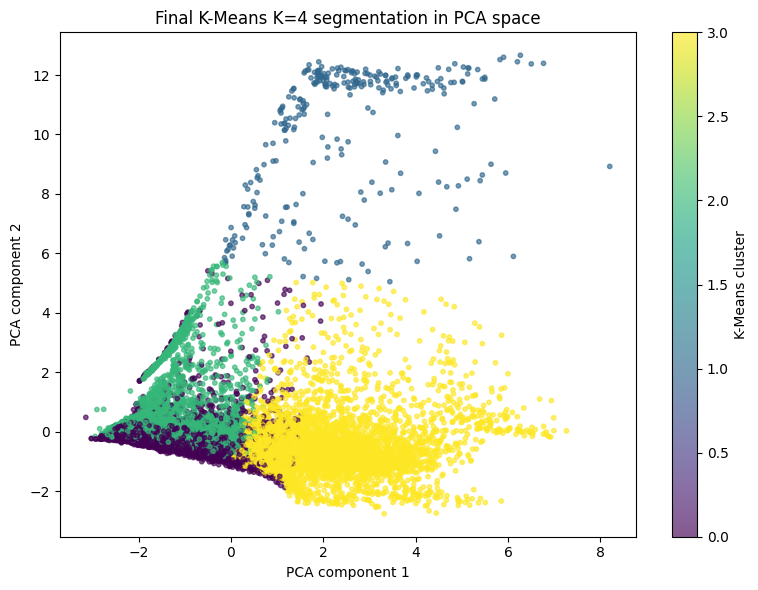

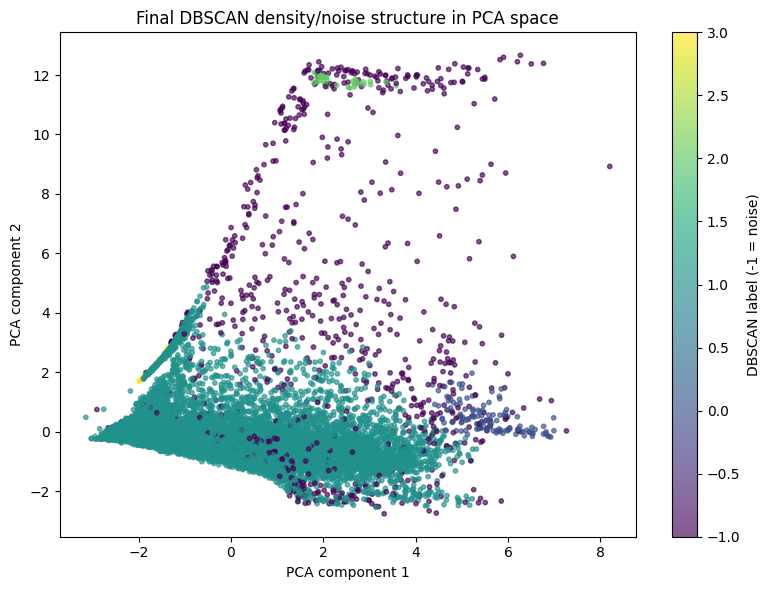

In [20]:
# ============================================================
# 17. PCA visual comparison: K-Means vs DBSCAN
# ============================================================

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["pca_1"], df["pca_2"], c=df["kmeans_cluster"], s=10, alpha=0.65)
plt.title("Final K-Means K=4 segmentation in PCA space")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(scatter, label="K-Means cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["pca_1"], df["pca_2"], c=df["dbscan_label"], s=10, alpha=0.65)
plt.title("Final DBSCAN density/noise structure in PCA space")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(scatter, label="DBSCAN label (-1 = noise)")
plt.tight_layout()
plt.show()


## 18. K-Means and DBSCAN alignment

### What we do
We compare final K-Means clusters with DBSCAN labels using a cross-tabulation and two agreement metrics.

### Why we do it
The two methods solve different problems, so perfect agreement is not expected. The comparison helps check whether DBSCAN mainly flags atypical customers across several K-Means segments or discovers dense subgroups within them.

### Expected outcome
A table showing how DBSCAN labels are distributed inside the final K-Means segments.


In [21]:
# ============================================================
# 18. K-Means vs DBSCAN alignment
# ============================================================

alignment_counts = pd.crosstab(df["kmeans_segment"], df["dbscan_group"])
alignment_pct = pd.crosstab(df["kmeans_segment"], df["dbscan_group"], normalize="index") * 100

print("K-Means vs DBSCAN counts:")
display(alignment_counts)

print("K-Means vs DBSCAN row percentages:")
display(alignment_pct.round(2))

# Agreement metrics are calculated on numerical labels. They are diagnostic only.
ari = adjusted_rand_score(df["kmeans_cluster"], df["dbscan_label"])
nmi = normalized_mutual_info_score(df["kmeans_cluster"], df["dbscan_label"])

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")
print("Interpretation: low or moderate alignment is acceptable because K-Means and DBSCAN answer different analytical questions.")


K-Means vs DBSCAN counts:


dbscan_group,Main dense customer population,Noise / atypical customer,Small hidden dense subgroup 1,Small hidden dense subgroup 2,Small hidden dense subgroup 3
kmeans_segment,,,,,
Churn-risk / declining,0,81,3830,0,30
Recent-growth / opportunity,0,253,0,34,0
Stable / lower-intensity customers,0,90,6075,0,0
Strategic / high-value active,123,404,5871,0,0


K-Means vs DBSCAN row percentages:


dbscan_group,Main dense customer population,Noise / atypical customer,Small hidden dense subgroup 1,Small hidden dense subgroup 2,Small hidden dense subgroup 3
kmeans_segment,,,,,
Churn-risk / declining,0.000,2.060,97.180,0.000,0.760
Recent-growth / opportunity,0.000,88.150,0.000,11.850,0.000
Stable / lower-intensity customers,0.000,1.460,98.540,0.000,0.000
Strategic / high-value active,1.920,6.310,91.760,0.000,0.000


Adjusted Rand Index: 0.0294
Normalized Mutual Information: 0.1037
Interpretation: low or moderate alignment is acceptable because K-Means and DBSCAN answer different analytical questions.


## 19. DBSCAN profiling: dense customers vs noise customers

### What we do
We compare DBSCAN noise customers with dense customers using business variables.

### Why we do it
This is the most useful business output of DBSCAN. Noise customers are customers whose behaviour is not located inside a sufficiently dense region of the standardized feature space.

### Expected outcome
A profile table showing whether atypical customers are larger, smaller, more volatile, more declining or more unusual than the dense population.


In [22]:
# ============================================================
# 19. DBSCAN profiling
# ============================================================

dbscan_profile = (
    df.groupby("dbscan_group")[BUSINESS_COLS]
    .agg(["count", "mean", "median"])
    .round(3)
)

print("DBSCAN group profile:")
display(dbscan_profile)

noise_vs_dense = (
    df.assign(density_status=np.where(df["is_dbscan_noise"], "Noise / atypical", "Dense"))
    .groupby("density_status")[BUSINESS_COLS]
    .mean()
    .T
    .round(3)
)

if set(["Dense", "Noise / atypical"]).issubset(noise_vs_dense.columns):
    noise_vs_dense["Noise / Dense ratio"] = (
        noise_vs_dense["Noise / atypical"] / noise_vs_dense["Dense"].replace(0, np.nan)
    ).round(3)

print("Noise versus dense comparison:")
display(noise_vs_dense)


DBSCAN group profile:


Revenue                             Employees                total_volume                         recent_volume                        past_volume  \
                                 count          mean        median     count    mean median        count        mean      median         count        mean     median       count   
dbscan_group                                                                                                                                                                        
Main dense customer population     123 4,967,464.252 1,635,689.000       123  15.415  8.000          123 491,331.447 277,170.000           123 120,023.000 74,925.000         123   
Noise / atypical customer          828 6,175,079.428   670,388.000       828 124.413 12.000          828  67,581.912   3,590.500           828  12,940.826    742.000         828   
Small hidden dense subgroup 1    15776 4,238,228.729   759,884.000     15776  18.959  5.000        15776   9,733.322     731.500         15776   1,349.645     13.000       15776   
Small hidden dense subgroup 2       34 3,799,047.912 3,074,471.000        34  14.206 11.500           34     587.529     341.500            34     586.941    341.500          34   
Small hidden dense subgroup 3       30         0.000         0.000        30   3.200  2.000           30       7.267       6.000            30       7.267      6.000          30   

                                                       avg_monthly_volume                      volume_trend                     trend_pct               volatility            \
                                      mean      median              count       mean    median        count      mean    median     count   mean median      count      mean   
dbscan_group                                                                                                                                                                   
Main dense customer population 371,308.447 204,547.000                123 13,648.096 7,699.167          123 7,626.885 5,169.067       123  1.133  0.752        123 6,788.459   
Noise / atypical customer       54,641.086     709.000                828  1,877.275    99.736          828   335.435    52.300       828 83.380  8.111        828 2,294.045   
Small hidden dense subgroup 1    8,383.677     656.000              15776    270.370    20.319        15776   -54.515    -3.233     15776 -0.145 -0.373      15776   173.690   
Small hidden dense subgroup 2        0.588       0.000                 34     16.320     9.486           34    97.804    56.917        34 95.581 56.917         34    59.396   
Small hidden dense subgroup 3        0.000       0.000                 30      0.202     0.167           30     1.211     1.000        30  1.211  1.000         30     1.189   

                                         cv_volume              recent_ratio              activity_drop_ratio                    
                                  median     count  mean median        count  mean median               count     mean   median  
dbscan_group                                                                                                                     
Main dense customer population 4,639.554       123 0.653  0.541          123 0.288  0.259                 123   -1.134   -0.752  
Noise / atypical customer        264.383       828 2.626  2.412          828 0.578  0.702                 828 -401.869  -10.633  
Small hidden dense subgroup 1     29.818     15776 1.463  1.300        15776 0.115  0.043               15776   -0.087    0.604  
Small hidden dense subgroup 2     38.086        34 3.423  3.530           34 0.997  0.997                  34 -551.268 -331.000  
Small hidden dense subgroup 3      1.000        30 0.965  0.857           30 0.864  0.857                  30   -7.267   -6.000

Noise versus dense comparison:


density_status,Dense,Noise / atypical,Noise / Dense ratio
Revenue,"4,234,947.200","6,175,079.428",1.458
Employees,18.892,124.413,6.585
total_volume,"13,406.431","67,581.912",5.041
recent_volume,"2,259.914","12,940.826",5.726
past_volume,"11,146.517","54,641.086",4.902
avg_monthly_volume,372.401,"1,877.275",5.041
volume_trend,5.102,335.435,65.746
trend_pct,0.071,83.380,"1,174.366"
volatility,224.091,"2,294.045",10.237
cv_volume,1.460,2.626,1.799


## 20. Final customer segmentation and profiling

### What we do
We create a final customer segmentation table based on the selected K-Means K=4 model and enrich it with DBSCAN anomaly information.

### Why we do it
The final business output should combine both models:

- K-Means tells us the main customer segment;
- DBSCAN tells us whether the customer is atypical within the behavioural space.

### Expected outcome
A final profile table that can be used in the thesis/report and exported as CSV.


In [23]:
# ============================================================
# 20. Final customer segmentation profile
# ============================================================

final_profile = (
    df.groupby(["kmeans_cluster", "kmeans_segment"])[BUSINESS_COLS]
    .agg(["count", "mean", "median"])
    .round(3)
)

print("Final K-Means K=4 customer segmentation profile:")
display(final_profile)

# Additional compact table for reporting.
compact_profile = (
    df.groupby(["kmeans_cluster", "kmeans_segment"])
    .agg(
        customers=("kmeans_cluster", "size"),
        avg_revenue=("Revenue", "mean") if "Revenue" in df.columns else ("kmeans_cluster", "size"),
        avg_employees=("Employees", "mean") if "Employees" in df.columns else ("kmeans_cluster", "size"),
        avg_total_volume=("total_volume", "mean"),
        avg_recent_volume=("recent_volume", "mean"),
        avg_trend_pct=("trend_pct", "mean"),
        avg_recent_ratio=("recent_ratio", "mean"),
        avg_activity_drop_ratio=("activity_drop_ratio", "mean"),
        dbscan_noise_share=("is_dbscan_noise", "mean"),
    )
    .reset_index()
)
compact_profile["customer_share_%"] = compact_profile["customers"] / len(df) * 100
compact_profile["dbscan_noise_share_%"] = compact_profile["dbscan_noise_share"] * 100
compact_profile = compact_profile.drop(columns=["dbscan_noise_share"])

print("Compact final profile:")
display(compact_profile.round(3))


Final K-Means K=4 customer segmentation profile:


Revenue                             Employees               total_volume                      recent_volume                      \
                                                    count          mean        median     count   mean median        count       mean    median         count      mean    median   
kmeans_cluster kmeans_segment                                                                                                                                                       
0              Churn-risk / declining                3941    43,661.624         0.000      3941  2.687  1.000         3941  1,077.213   416.000          3941    71.238     0.000   
1              Recent-growth / opportunity            287 5,608,010.143 1,738,573.000       287 25.369 11.000          287  6,007.606   673.000           287 5,667.017   667.000   
2              Stable / lower-intensity customers    6165 6,552,347.474 2,549,600.000      6165 32.322 12.000         6165    262.406    67.000          6165    13.432     0.000   
3              Strategic / high-value active         6398 4,773,153.543 1,112,951.000      6398 29.299  7.000         6398 41,009.293 8,720.000          6398 7,002.191 1,036.000   

                                                  past_volume                      avg_monthly_volume                   volume_trend                 trend_pct                 \
                                                        count       mean    median              count      mean  median        count    mean  median     count    mean median   
kmeans_cluster kmeans_segment                                                                                                                                                   
0              Churn-risk / declining                    3941  1,005.975   365.000               3941    29.923  11.556         3941 -21.659  -4.667      3941  -0.238 -0.600   
1              Recent-growth / opportunity                287    340.589     0.000                287   166.878  18.694          287 933.150 111.033       287 242.533 48.833   
2              Stable / lower-intensity customers        6165    248.975    59.000               6165     7.289   1.861         6165  -6.061  -1.100      6165  -0.085 -0.464   
3              Strategic / high-value active             6398 34,007.102 7,381.000               6398 1,139.147 242.222         6398  33.462 -21.817      6398   0.317 -0.131   

                                                  volatility                 cv_volume              recent_ratio              activity_drop_ratio                      
                                                       count    mean  median     count  mean median        count  mean median               count       mean   median  
kmeans_cluster kmeans_segment                                                                                                                                          
0              Churn-risk / declining                   3941  53.384  19.233      3941 1.761  1.544         3941 0.086  0.000                3941      0.068    0.808  
1              Recent-growth / opportunity               287 493.933  71.581       287 3.641  3.497          287 0.974  0.994                 287 -1,208.398 -200.000  
2              Stable / lower-intensity customers       6165  17.821   5.942      6165 1.868  1.629         6165 0.113  0.000                6165     -0.736    0.800  
3              Strategic / high-value active            6398 783.780 185.134      6398 0.933  0.724         6398 0.166  0.148                6398     -0.334    0.131

Compact final profile:


,kmeans_cluster,kmeans_segment,customers,avg_revenue,avg_employees,avg_total_volume,avg_recent_volume,avg_trend_pct,avg_recent_ratio,avg_activity_drop_ratio,customer_share_%,dbscan_noise_share_%
0,0,Churn-risk / declining,3941,"43,661.624",2.687,"1,077.213",71.238,-0.238,0.086,0.068,23.471,2.055
1,1,Recent-growth / opportunity,287,"5,608,010.143",25.369,"6,007.606","5,667.017",242.533,0.974,"-1,208.398",1.709,88.153
2,2,Stable / lower-intensity customers,6165,"6,552,347.474",32.322,262.406,13.432,-0.085,0.113,-0.736,36.716,1.460
3,3,Strategic / high-value active,6398,"4,773,153.543",29.299,"41,009.293","7,002.191",0.317,0.166,-0.334,38.104,6.314


## 21. Optional categorical profiling: sector and geography

### What we do
If sector or geographical variables exist, we display the most frequent categories inside each final K-Means segment.

### Why we do it
Customer segmentation becomes more actionable when behavioural clusters are connected to market characteristics such as region, province or sector.

### Expected outcome
Tables showing the top categories by segment where the relevant columns are available.


In [24]:
# ============================================================
# 21. Optional categorical profiling
# ============================================================

CATEGORICAL_CANDIDATES = ["Region", "Province", "NACE", "NACE_Desc", "Nature"]
cat_cols = [col for col in CATEGORICAL_CANDIDATES if col in df.columns]

if not cat_cols:
    print("No categorical profiling columns found.")
else:
    for cat_col in cat_cols:
        print(f"Top {cat_col} categories by K-Means segment:")
        top_rows = []
        for segment, group in df.groupby("kmeans_segment"):
            counts = group[cat_col].value_counts(dropna=False).head(5)
            for category, count in counts.items():
                top_rows.append({
                    "kmeans_segment": segment,
                    cat_col: category,
                    "customers": int(count),
                    "share_within_segment_%": count / len(group) * 100,
                })
        top_table = pd.DataFrame(top_rows)
        display(top_table.round(2))


Top Region categories by K-Means segment:


,kmeans_segment,Region,customers,share_within_segment_%
0,Churn-risk / declining,Lombardia,596,15.120
1,Churn-risk / declining,Lazio,512,12.990
2,Churn-risk / declining,Toscana,443,11.240
3,Churn-risk / declining,Emilia-Romagna,414,10.500
4,Churn-risk / declining,Veneto,343,8.700
5,Recent-growth / opportunity,Lombardia,79,27.530
6,Recent-growth / opportunity,Emilia-Romagna,37,12.890
7,Recent-growth / opportunity,Lazio,27,9.410
8,Recent-growth / opportunity,Sicilia,26,9.060
9,Recent-growth / opportunity,Veneto,25,8.710


Top Province categories by K-Means segment:


,kmeans_segment,Province,customers,share_within_segment_%
0,Churn-risk / declining,RM,430,10.910
1,Churn-risk / declining,MI,249,6.320
2,Churn-risk / declining,FI,146,3.700
3,Churn-risk / declining,TO,141,3.580
4,Churn-risk / declining,CT,110,2.790
5,Recent-growth / opportunity,MI,25,8.710
6,Recent-growth / opportunity,RM,23,8.010
7,Recent-growth / opportunity,BS,18,6.270
8,Recent-growth / opportunity,FI,10,3.480
9,Recent-growth / opportunity,BO,10,3.480


Top NACE categories by K-Means segment:


,kmeans_segment,NACE,customers,share_within_segment_%
0,Churn-risk / declining,47.910,479,12.150
1,Churn-risk / declining,47.710,142,3.600
2,Churn-risk / declining,47.780,96,2.440
3,Churn-risk / declining,53.200,93,2.360
4,Churn-risk / declining,1.210,86,2.180
5,Recent-growth / opportunity,47.910,26,9.060
6,Recent-growth / opportunity,46.490,9,3.140
7,Recent-growth / opportunity,52.290,7,2.440
8,Recent-growth / opportunity,46.470,6,2.090
9,Recent-growth / opportunity,53.200,6,2.090


Top NACE_Desc categories by K-Means segment:


,kmeans_segment,NACE_Desc,customers,share_within_segment_%
0,Churn-risk / declining,Retail sale via mail order houses or via Internet,479,12.150
1,Churn-risk / declining,Retail sale of clothing in specialised stores,142,3.600
2,Churn-risk / declining,Other retail sale of new goods in specialised ...,96,2.440
3,Churn-risk / declining,Other postal and courier activities,93,2.360
4,Churn-risk / declining,Growing of grapes,86,2.180
5,Recent-growth / opportunity,Retail sale via mail order houses or via Internet,26,9.060
6,Recent-growth / opportunity,Wholesale of other household goods,9,3.140
7,Recent-growth / opportunity,Other transportation support activities,7,2.440
8,Recent-growth / opportunity,"Wholesale of furniture, carpets and lighting e...",6,2.090
9,Recent-growth / opportunity,Other postal and courier activities,6,2.090


## 22. Final visual summary

### What we do
We plot the final segment sizes and the share of DBSCAN noise customers inside each K-Means segment.

### Why we do it
These two visuals summarize the managerial interpretation:

- how large each business segment is;
- which segments contain more atypical customers.

### Expected outcome
Two final graphs suitable for reporting or presentation.


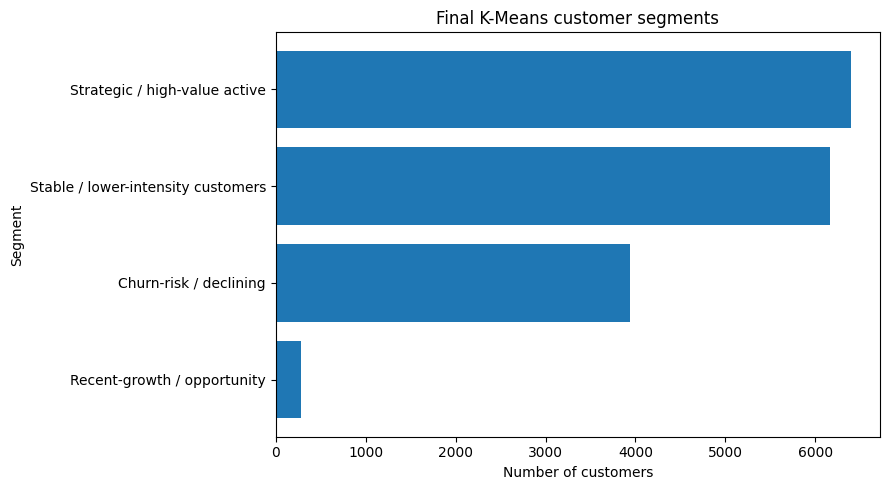

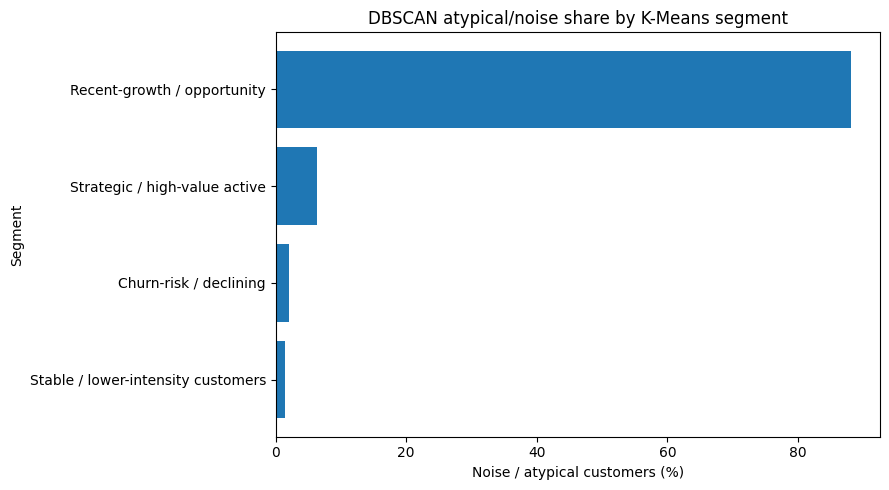

In [25]:
# ============================================================
# 22. Final visual summary
# ============================================================

segment_counts = df["kmeans_segment"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(segment_counts.index, segment_counts.values)
plt.title("Final K-Means customer segments")
plt.xlabel("Number of customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

noise_by_segment = (
    df.groupby("kmeans_segment")["is_dbscan_noise"]
    .mean()
    .sort_values(ascending=True) * 100
)

plt.figure(figsize=(9, 5))
plt.barh(noise_by_segment.index, noise_by_segment.values)
plt.title("DBSCAN atypical/noise share by K-Means segment")
plt.xlabel("Noise / atypical customers (%)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()


## 23. Export outputs

### What we do
We save the final dataset and profile tables as CSV files.

### Why we do it
The outputs can be reused in later notebooks for risk scoring, churn-status labelling, supervised models and SHAP explainability.

### Expected outcome
The following files are created in the notebook folder:

- `dataset_clustered_kmeans_dbscan_best.csv`
- `customer_segmentation_profile_best.csv`
- `kmeans_comparison_results_best.csv`
- `dbscan_parameter_results_best.csv`


In [26]:
# ============================================================
# 23. Export outputs
# ============================================================

clustered_output = OUTPUT_DIR / "dataset_clustered_kmeans_dbscan_best.csv"
profile_output = OUTPUT_DIR / "customer_segmentation_profile_best.csv"
kmeans_output = OUTPUT_DIR / "kmeans_comparison_results_best.csv"
dbscan_output = OUTPUT_DIR / "dbscan_parameter_results_best.csv"

# Save full clustered dataset.
df.to_csv(clustered_output, index=False)

# Save compact profile.
compact_profile.to_csv(profile_output, index=False)

# Save model comparison tables.
kmeans_comparison.to_csv(kmeans_output, index=False)
dbscan_results[DBSCAN_DISPLAY_COLS].to_csv(dbscan_output, index=False)

print("Saved outputs:")
print("-", clustered_output.resolve())
print("-", profile_output.resolve())
print("-", kmeans_output.resolve())
print("-", dbscan_output.resolve())


Saved outputs:
- /Users/sara/Desktop/Master RBS/10 Capstone/data/dataset_clustered_kmeans_dbscan_best.csv
- /Users/sara/Desktop/Master RBS/10 Capstone/data/customer_segmentation_profile_best.csv
- /Users/sara/Desktop/Master RBS/10 Capstone/data/kmeans_comparison_results_best.csv
- /Users/sara/Desktop/Master RBS/10 Capstone/data/dbscan_parameter_results_best.csv


## 24. Final methodological conclusion

The final workflow is now coherent and thesis-ready:

1. The stronger 11-feature matrix from the original K-Means analysis is retained.
2. Capping and standardization are performed once and reused by both K-Means and DBSCAN.
3. K-Means is compared for K=3, K=4 and K=5 using metrics, profiles, transition tables and PCA plots.
4. K=4 is selected because it offers the best balance between interpretability and segmentation granularity.
5. DBSCAN uses the same feature matrix and the consistent rule `min_samples = 2 × 11 = 22`.
6. DBSCAN is interpreted as a complementary anomaly/density layer, not as the main segmentation model.
7. The final profiling connects technical cluster outputs to business variables and customer-management actions.
